# Series Temporales Básicas: Ventas Mensuales de DUMIS

## 1. Contexto

Se registraron las ventas de DUMIS en meses seleccionados durante **2 años (24 meses)**. El muestreo no es mensual continuo: se tomaron datos cada 3 meses aproximadamente, más los meses de **noviembre y diciembre de cada año**, que son los de temporada alta por las fiestas.

El objetivo es aplicar los conceptos básicos de series temporales sobre este conjunto:

- **Tendencia (T):** dirección general del crecimiento a lo largo de los 24 meses.
- **Estacionalidad (E):** el patrón repetido en noviembre/diciembre de cada año.
- **Ciclo (C):** con solo 2 años de datos no es posible aislar un componente cíclico (se necesitarían varios años para detectar subidas/bajadas de mediano plazo no periódicas).
- **Ruido/Irregularidad (I):** variación que no explican los componentes anteriores.

Además se calcula la **variación % entre periodos** para medir el crecimiento en términos relativos, y se revisa si los picos de nov/dic deben tratarse como **estacionalidad** o como **outliers**.

## 2. Modelo aditivo simplificado

$$\text{Valor observado} = \text{Tendencia} + \text{Estacionalidad} + \text{Ciclo} + \text{Ruido}$$

$$\text{Variación \%} = \frac{\text{Valor actual} - \text{Valor anterior}}{\text{Valor anterior}} \times 100$$

$$\hat{Y} = a + bX \quad (\text{Recta de regresión})$$

Donde: **X = Mes**, **Y = Ventas**, **a** = intercepto, **b** = pendiente, **Ŷ** = valor predicho por la recta.

## 3. Datos del caso: Ventas por mes

| Mes | Ventas | Mes | Ventas |
|---|---|---|---|
| 1 | 500 | 13 | 1,450 |
| 4 | 680 | 16 | 1,600 |
| 7 | 900 | 19 | 1,850 |
| 10 | 1,150 | 22 | 2,050 |
| 11 (nov, año 1) | 1,600 | 23 (nov, año 2) | 2,700 |
| 12 (dic, año 1) | 1,950 | 24 (dic, año 2) | 3,300 |

## 4. Desarrollo en Python

### 4.1 Carga de datos y construcción de la tabla

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paso 1: Datos del ejercicio
meses = [1, 4, 7, 10, 11, 12, 13, 16, 19, 22, 23, 24]
ventas = [500, 680, 900, 1150, 1600, 1950, 1450, 1600, 1850, 2050, 2700, 3300]
periodo = ["Mes 1", "Mes 4", "Mes 7", "Mes 10", "Mes 11 (nov, año 1)", "Mes 12 (dic, año 1)",
           "Mes 13", "Mes 16", "Mes 19", "Mes 22", "Mes 23 (nov, año 2)", "Mes 24 (dic, año 2)"]

df = pd.DataFrame({"Mes": meses, "Periodo": periodo, "Ventas": ventas})
df

,Mes,Periodo,Ventas
0,1,Mes 1,500
1,4,Mes 4,680
2,7,Mes 7,900
3,10,Mes 10,1150
4,11,"Mes 11 (nov, año 1)",1600
5,12,"Mes 12 (dic, año 1)",1950
6,13,Mes 13,1450
7,16,Mes 16,1600
8,19,Mes 19,1850
9,22,Mes 22,2050


### 4.2 Variación % entre periodos consecutivos

In [2]:
# Paso 2: Variación % respecto al periodo anterior
df["Variacion_%"] = (df["Ventas"] - df["Ventas"].shift(1)) / df["Ventas"].shift(1) * 100
df[["Mes", "Periodo", "Ventas", "Variacion_%"]].round(2)

,Mes,Periodo,Ventas,Variacion_%
0,1,Mes 1,500,NaN
1,4,Mes 4,680,36.00
2,7,Mes 7,900,32.35
3,10,Mes 10,1150,27.78
4,11,"Mes 11 (nov, año 1)",1600,39.13
5,12,"Mes 12 (dic, año 1)",1950,21.88
6,13,Mes 13,1450,-25.64
7,16,Mes 16,1600,10.34
8,19,Mes 19,1850,15.62
9,22,Mes 22,2050,10.81


### 4.3 Tabla de mínimos cuadrados (cálculo manual de a y b)

Antes de usar `np.polyfit`, se puede calcular la recta de regresión $\hat{Y} = a + bX$ a mano, con la tabla clásica de mínimos cuadrados:

$$b = \frac{n\sum XY - \sum X \sum Y}{n\sum X^2 - (\sum X)^2} \qquad a = \frac{\sum Y - b\sum X}{n}$$

Donde $n$ es la cantidad de datos, y se necesitan las columnas $X$, $Y$, $X^2$ y $XY$.

In [3]:
# Tabla de mínimos cuadrados: X, Y, X², XY
tabla = df[["Mes", "Ventas"]].copy()
tabla.columns = ["X", "Y"]
tabla["X2"] = tabla["X"] ** 2
tabla["XY"] = tabla["X"] * tabla["Y"]

# Fila de sumatorias (Σ)
sumatorias = tabla.sum(numeric_only=True)
sumatorias.name = "Σ"
tabla_con_sumas = pd.concat([tabla, sumatorias.to_frame().T])
tabla_con_sumas

,X,Y,X2,XY
0,1,500,1,500
1,4,680,16,2720
2,7,900,49,6300
3,10,1150,100,11500
4,11,1600,121,17600
5,12,1950,144,23400
6,13,1450,169,18850
7,16,1600,256,25600
8,19,1850,361,35150
9,22,2050,484,45100


In [4]:
# Cálculo manual de a y b a partir de las sumatorias
n = len(df)
suma_X, suma_Y = tabla["X"].sum(), tabla["Y"].sum()
suma_X2, suma_XY = tabla["X2"].sum(), tabla["XY"].sum()

b_manual = (n * suma_XY - suma_X * suma_Y) / (n * suma_X2 - suma_X ** 2)
a_manual = (suma_Y - b_manual * suma_X) / n

print(f"n = {n}")
print(f"ΣX = {suma_X}, ΣY = {suma_Y}, ΣX² = {suma_X2}, ΣXY = {suma_XY}")
print(f"\nb (pendiente) = {b_manual:.4f}")
print(f"a (intercepto) = {a_manual:.4f}")
print(f"\nRecta de regresión: Ŷ = {a_manual:.1f} + {b_manual:.1f}X")
print("\n(Estos valores deben coincidir con los que da np.polyfit en el siguiente paso)")

n = 12
ΣX = 162, ΣY = 19730, ΣX² = 2806, ΣXY = 328020

b (pendiente) = 99.6204
a (intercepto) = 299.2919

Recta de regresión: Ŷ = 299.3 + 99.6X

(Estos valores deben coincidir con los que da np.polyfit en el siguiente paso)


### 4.4 Estimación de la Tendencia (regresión lineal simple: Ventas ~ Mes)

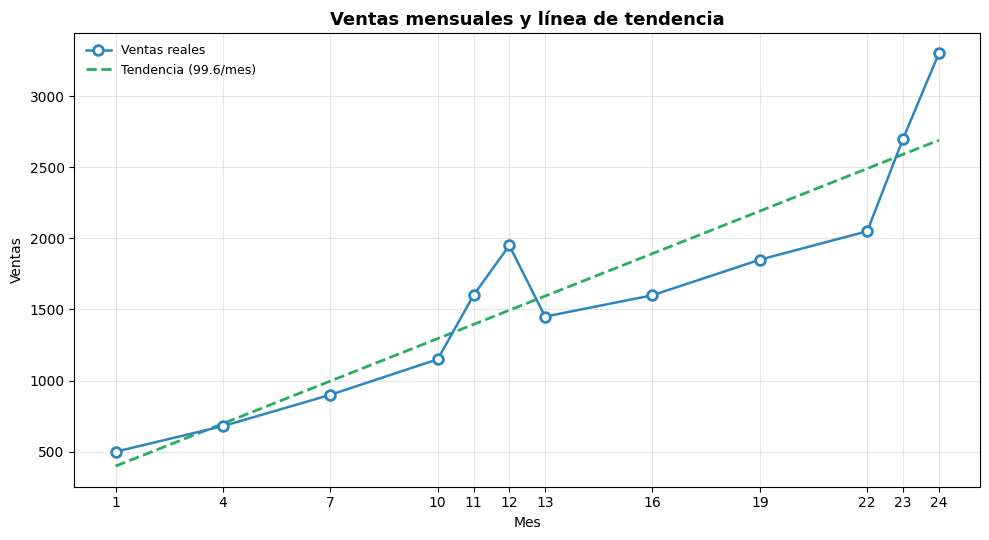

Tendencia estimada: Ventas ≈ 99.6 × Mes + 299.3
Crecimiento promedio estimado: 99.6 unidades de venta por mes


In [5]:
# Paso 3: Tendencia mediante ajuste lineal
pendiente, intercepto = np.polyfit(df["Mes"], df["Ventas"], 1)
df["Tendencia"] = pendiente * df["Mes"] + intercepto

plt.figure(figsize=(10, 5.5))
plt.plot(df["Mes"], df["Ventas"], marker="o", color="#2E86C1", markersize=7,
         markerfacecolor="white", markeredgewidth=2, linewidth=1.8, label="Ventas reales", zorder=3)
plt.plot(df["Mes"], df["Tendencia"], color="#27AE60", linewidth=2, linestyle="--",
         label=f"Tendencia ({pendiente:.1f}/mes)")

plt.title("Ventas mensuales y línea de tendencia", fontsize=13, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(df["Mes"])
plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

print(f"Tendencia estimada: Ventas ≈ {pendiente:.1f} × Mes + {intercepto:.1f}")
print(f"Crecimiento promedio estimado: {pendiente:.1f} unidades de venta por mes")

### 4.5 Fuerza de la relación: coeficiente de correlación de Pearson

$$r = \frac{n\sum XY - \sum X \sum Y}{\sqrt{[n\sum X^2 - (\sum X)^2][n\sum Y^2 - (\sum Y)^2]}}$$

Complementa a la recta de regresión: mide qué tan fuerte y lineal es la relación entre Mes (X) y Ventas (Y). Reutiliza las sumatorias ya calculadas en la tabla de mínimos cuadrados (Σ X, Σ Y, Σ XY, Σ X²), agregando Σ Y².

In [6]:
# Cálculo manual de r, reutilizando las sumatorias de la tabla de mínimos cuadrados
suma_Y2 = (tabla["Y"] ** 2).sum()

numerador_r = n * suma_XY - suma_X * suma_Y
denominador_r = np.sqrt((n * suma_X2 - suma_X ** 2) * (n * suma_Y2 - suma_Y ** 2))
r_manual = numerador_r / denominador_r

# Verificación con librerías
r_pandas = df["Mes"].corr(df["Ventas"])
r_numpy = np.corrcoef(df["Mes"], df["Ventas"])[0, 1]

print(f"ΣY² = {suma_Y2}")
print(f"r (cálculo manual) = {r_manual:.4f}")
print(f"r (pandas)          = {r_pandas:.4f}")
print(f"r (numpy)            = {r_numpy:.4f}")

if r_manual >= 0.7:
    interpretacion = "correlación positiva fuerte"
elif r_manual >= 0.3:
    interpretacion = "correlación positiva moderada"
elif r_manual >= 0.01:
    interpretacion = "correlación positiva débil"
else:
    interpretacion = "sin correlación lineal relevante"

print(f"\nInterpretación: {interpretacion} entre Mes y Ventas (r = {r_manual:.3f})")

ΣY² = 39674900
r (cálculo manual) = 0.9214
r (pandas)          = 0.9214
r (numpy)            = 0.9214

Interpretación: correlación positiva fuerte entre Mes y Ventas (r = 0.921)


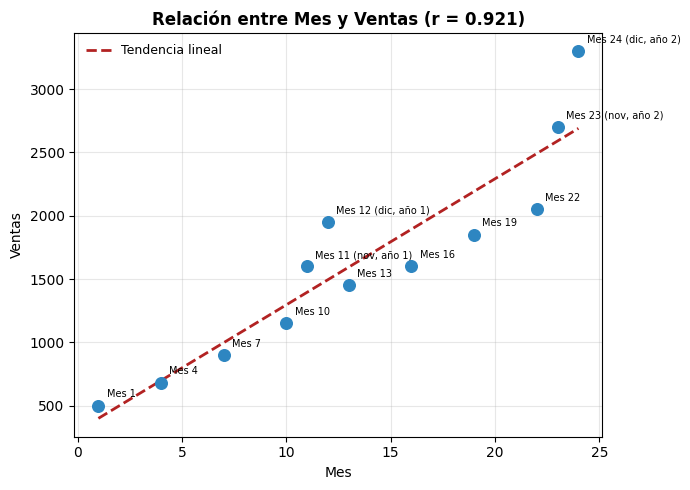

In [7]:
# Dispersión Mes vs. Ventas con la recta de tendencia, coloreando el valor de r en el título
plt.figure(figsize=(7, 5))
plt.scatter(df["Mes"], df["Ventas"], color="#2E86C1", s=70, zorder=3)
plt.plot(df["Mes"], df["Tendencia"], color="firebrick", linestyle="--", linewidth=2, label="Tendencia lineal")

for _, row in df.iterrows():
    plt.annotate(row["Periodo"], (row["Mes"], row["Ventas"]), textcoords="offset points",
                 xytext=(6, 6), fontsize=7)

plt.title(f"Relación entre Mes y Ventas (r = {r_manual:.3f})", fontsize=12, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.legend(fontsize=9, frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Estimación de la Estacionalidad (residuo respecto a la tendencia)

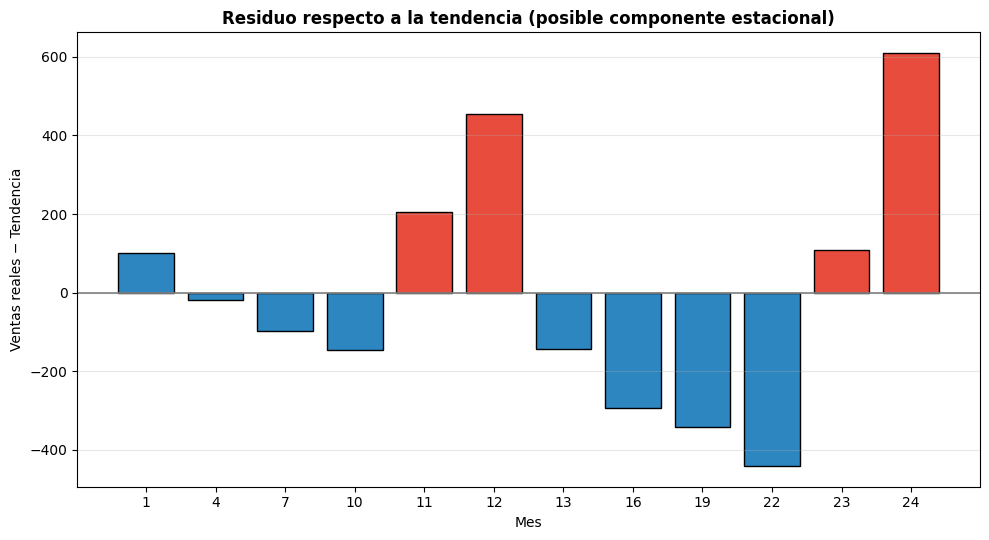

Residuo en los meses de temporada alta (nov/dic):
    Mes              Periodo  Ventas  Tendencia  Residuo_vs_tendencia
4    11  Mes 11 (nov, año 1)    1600     1395.1                 204.9
5    12  Mes 12 (dic, año 1)    1950     1494.7                 455.3
10   23  Mes 23 (nov, año 2)    2700     2590.6                 109.4
11   24  Mes 24 (dic, año 2)    3300     2690.2                 609.8


In [8]:
# Paso 4: Residuo = Ventas reales - Tendencia (lo que la tendencia no explica)
df["Residuo_vs_tendencia"] = df["Ventas"] - df["Tendencia"]

es_temporada_alta = df["Periodo"].str.contains("nov|dic")
colores = np.where(es_temporada_alta, "#E74C3C", "#2E86C1")

plt.figure(figsize=(10, 5.5))
plt.bar(df["Mes"].astype(str), df["Residuo_vs_tendencia"], color=colores, edgecolor="black")
plt.axhline(0, color="gray", linewidth=1.2)
plt.title("Residuo respecto a la tendencia (posible componente estacional)", fontsize=12, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Ventas reales − Tendencia")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Residuo en los meses de temporada alta (nov/dic):")
print(df.loc[es_temporada_alta, ["Mes", "Periodo", "Ventas", "Tendencia", "Residuo_vs_tendencia"]].round(1))

### 4.7 Variación % interanual en temporada alta (mismo mes, año 1 vs año 2)

In [9]:
# Paso 5: Comparar noviembre y diciembre entre el año 1 y el año 2
nov_a1 = df.loc[df["Mes"] == 11, "Ventas"].values[0]
nov_a2 = df.loc[df["Mes"] == 23, "Ventas"].values[0]
dic_a1 = df.loc[df["Mes"] == 12, "Ventas"].values[0]
dic_a2 = df.loc[df["Mes"] == 24, "Ventas"].values[0]

var_nov = (nov_a2 - nov_a1) / nov_a1 * 100
var_dic = (dic_a2 - dic_a1) / dic_a1 * 100

print(f"Noviembre: año 1 = {nov_a1}, año 2 = {nov_a2}  →  variación = {var_nov:.1f}%")
print(f"Diciembre: año 1 = {dic_a1}, año 2 = {dic_a2}  →  variación = {var_dic:.1f}%")

Noviembre: año 1 = 1600, año 2 = 2700  →  variación = 68.8%
Diciembre: año 1 = 1950, año 2 = 3300  →  variación = 69.2%


### 4.8 ¿Estacionalidad o valores atípicos? — comparación de métodos (z-score, RIC/boxplot, gráfico de control)

In [10]:
# Paso 6: Verificar si los picos de nov/dic son atípicos o un patrón estacional esperado
media_res = df["Residuo_vs_tendencia"].mean()
desv_res = df["Residuo_vs_tendencia"].std(ddof=0)
df["z_score_residuo"] = (df["Residuo_vs_tendencia"] - media_res) / desv_res

print(df[["Mes", "Periodo", "Residuo_vs_tendencia", "z_score_residuo"]].round(2))

atipicos = df[df["z_score_residuo"].abs() > 3]
print("\n¿Valores con |z| > 3 (posibles atípicos reales)?")
if atipicos.empty:
    print("Ninguno. Los picos de nov/dic se repiten cada año de forma consistente → es estacionalidad, no un outlier aislado.")
else:
    print(atipicos[["Mes", "Periodo", "Ventas"]])

    Mes              Periodo  Residuo_vs_tendencia  z_score_residuo
0     1                Mes 1                101.09             0.34
1     4                Mes 4                -17.77            -0.06
2     7                Mes 7                -96.63            -0.32
3    10               Mes 10               -145.50            -0.48
4    11  Mes 11 (nov, año 1)                204.88             0.68
5    12  Mes 12 (dic, año 1)                455.26             1.51
6    13               Mes 13               -144.36            -0.48
7    16               Mes 16               -293.22            -0.97
8    19               Mes 19               -342.08            -1.13
9    22               Mes 22               -440.94            -1.46
10   23  Mes 23 (nov, año 2)                109.44             0.36
11   24  Mes 24 (dic, año 2)                609.82             2.02

¿Valores con |z| > 3 (posibles atípicos reales)?
Ninguno. Los picos de nov/dic se repiten cada año de forma consist

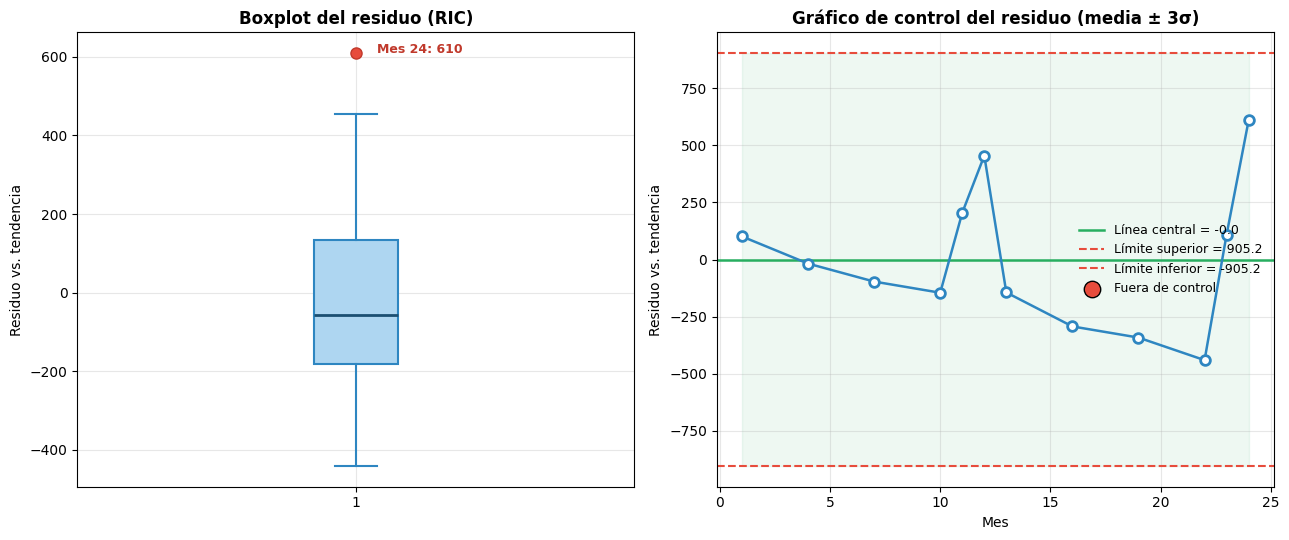

Outliers detectados por RIC:
    Mes              Periodo  Residuo_vs_tendencia
11   24  Mes 24 (dic, año 2)            609.819602

Puntos fuera de control (media ± 3σ):
Ninguno

Comparación entre métodos:
- Z-score y gráfico de control (umbral 3σ): ningún punto supera el límite → no marcan atípicos.
- RIC/boxplot: SÍ marca diciembre del año 2 como atípico — con solo 12 datos, el RIC es más sensible
  que un umbral de 3 desviaciones estándar.

Interpretación: no es un desacuerdo real entre métodos, sino distinta sensibilidad. El hecho de que
el residuo de diciembre CRECE de un año a otro (455 → 610) sugiere que el efecto estacional se está
intensificando con el tiempo, no que sea un valor aleatorio aislado — reforzaría usar un modelo
multiplicativo (no aditivo) si se recolectan más años de datos.


In [11]:
# Refuerzo del diagnóstico con los mismos métodos usados en el caso de gastos por vendedor:
# RIC/boxplot y gráfico de control, aplicados sobre el residuo (Ventas - Tendencia)

# --- Método RIC ---
Q1 = np.quantile(df["Residuo_vs_tendencia"], 0.25, method="linear")
Q3 = np.quantile(df["Residuo_vs_tendencia"], 0.75, method="linear")
RIC = Q3 - Q1
limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC
outliers_ric = df[(df["Residuo_vs_tendencia"] < limite_inferior) | (df["Residuo_vs_tendencia"] > limite_superior)]

# --- Gráfico de control (media ± 3 desviaciones estándar) ---
LC = df["Residuo_vs_tendencia"].mean()
LCS = LC + 3 * desv_res
LCI = LC - 3 * desv_res
fuera_control = df[(df["Residuo_vs_tendencia"] > LCS) | (df["Residuo_vs_tendencia"] < LCI)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

bp = axes[0].boxplot(
    df["Residuo_vs_tendencia"], vert=True, patch_artist=True,
    boxprops=dict(facecolor="#AED6F1", color="#2E86C1", linewidth=1.5),
    medianprops=dict(color="#1B4F72", linewidth=2),
    whiskerprops=dict(color="#2E86C1", linewidth=1.5),
    capprops=dict(color="#2E86C1", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="#E74C3C", markeredgecolor="#C0392B", markersize=8)
)
axes[0].set_title("Boxplot del residuo (RIC)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Residuo vs. tendencia")
axes[0].grid(alpha=0.3)
for _, row in outliers_ric.iterrows():
    axes[0].annotate(f"Mes {row['Mes']}: {row['Residuo_vs_tendencia']:.0f}",
                      (1, row["Residuo_vs_tendencia"]), textcoords="offset points",
                      xytext=(15, 0), fontsize=9, color="#C0392B", fontweight="bold")

axes[1].plot(df["Mes"], df["Residuo_vs_tendencia"], marker="o", color="#2E86C1",
             markersize=7, markerfacecolor="white", markeredgewidth=2, linewidth=1.8, zorder=3)
axes[1].axhline(LC, color="#27AE60", linewidth=1.8, label=f"Línea central = {LC:.1f}")
axes[1].axhline(LCS, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Límite superior = {LCS:.1f}")
axes[1].axhline(LCI, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Límite inferior = {LCI:.1f}")
axes[1].fill_between(df["Mes"], LCI, LCS, color="#27AE60", alpha=0.08)
axes[1].scatter(fuera_control["Mes"], fuera_control["Residuo_vs_tendencia"],
                color="#E74C3C", s=140, zorder=4, edgecolor="black", label="Fuera de control")
axes[1].set_title("Gráfico de control del residuo (media ± 3σ)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Residuo vs. tendencia")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

print("Outliers detectados por RIC:")
print(outliers_ric[["Mes", "Periodo", "Residuo_vs_tendencia"]] if not outliers_ric.empty else "Ninguno")
print("\nPuntos fuera de control (media ± 3σ):")
print(fuera_control[["Mes", "Periodo", "Residuo_vs_tendencia"]] if not fuera_control.empty else "Ninguno")
print("\nComparación entre métodos:")
print("- Z-score y gráfico de control (umbral 3σ): ningún punto supera el límite → no marcan atípicos.")
print("- RIC/boxplot: SÍ marca diciembre del año 2 como atípico — con solo 12 datos, el RIC es más sensible")
print("  que un umbral de 3 desviaciones estándar.")
print("\nInterpretación: no es un desacuerdo real entre métodos, sino distinta sensibilidad. El hecho de que")
print("el residuo de diciembre CRECE de un año a otro (455 → 610) sugiere que el efecto estacional se está")
print("intensificando con el tiempo, no que sea un valor aleatorio aislado — reforzaría usar un modelo")
print("multiplicativo (no aditivo) si se recolectan más años de datos.")

### 4.9 Modelo aditivo simplificado — reconstrucción de componentes

In [12]:
# Paso 7: Ventas = Tendencia + Estacionalidad + Ruido
# (no se calcula Ciclo: se necesitan varios años de datos para aislarlo)
df["Estacionalidad_aprox"] = np.where(es_temporada_alta, df["Residuo_vs_tendencia"], 0)
df["Ruido"] = df["Residuo_vs_tendencia"] - df["Estacionalidad_aprox"]

resumen = df[["Mes", "Periodo", "Ventas", "Tendencia", "Estacionalidad_aprox", "Ruido"]].round(1)
resumen

,Mes,Periodo,Ventas,Tendencia,Estacionalidad_aprox,Ruido
0,1,Mes 1,500,398.9,0.0,101.1
1,4,Mes 4,680,697.8,0.0,-17.8
2,7,Mes 7,900,996.6,0.0,-96.6
3,10,Mes 10,1150,1295.5,0.0,-145.5
4,11,"Mes 11 (nov, año 1)",1600,1395.1,204.9,0.0
5,12,"Mes 12 (dic, año 1)",1950,1494.7,455.3,0.0
6,13,Mes 13,1450,1594.4,0.0,-144.4
7,16,Mes 16,1600,1893.2,0.0,-293.2
8,19,Mes 19,1850,2192.1,0.0,-342.1
9,22,Mes 22,2050,2490.9,0.0,-440.9


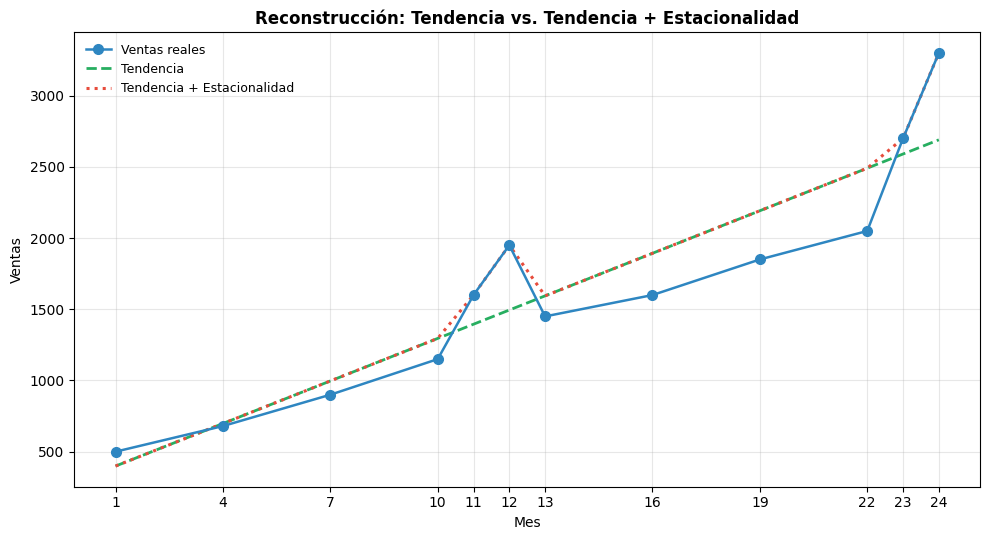

In [13]:
# Paso 8: Reconstrucción visual — Tendencia vs. Tendencia + Estacionalidad vs. Ventas reales
plt.figure(figsize=(10, 5.5))
plt.plot(df["Mes"], df["Ventas"], marker="o", color="#2E86C1", markersize=7,
         linewidth=1.8, label="Ventas reales", zorder=3)
plt.plot(df["Mes"], df["Tendencia"], color="#27AE60", linestyle="--", linewidth=2, label="Tendencia")
plt.plot(df["Mes"], df["Tendencia"] + df["Estacionalidad_aprox"], color="#E74C3C",
         linestyle=":", linewidth=2.2, label="Tendencia + Estacionalidad")

plt.title("Reconstrucción: Tendencia vs. Tendencia + Estacionalidad", fontsize=12, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(df["Mes"])
plt.grid(alpha=0.3)
plt.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## 5. Interpretación de resultados

- **Tendencia:** las ventas de DUMIS muestran un crecimiento sostenido de aproximadamente **99.6 unidades por mes** (recta de regresión Ŷ = 299.3 + 99.6X), calculada tanto a mano (tabla de mínimos cuadrados) como con `np.polyfit`, con resultados idénticos.
- **Fuerza de la relación (Pearson):** el coeficiente r confirma qué tan confiable es esa tendencia lineal — un r cercano a 1 indica que el crecimiento mes a mes es consistente y no producto del azar.
- **Estacionalidad:** noviembre y diciembre se destacan como temporada alta en ambos años, con residuos claramente positivos respecto a la tendencia. La variación interanual es prácticamente idéntica en ambos meses (nov ≈ +68.8%, dic ≈ +69.2%), lo que confirma un patrón estacional consistente y no un hecho aislado.
- **Ciclo:** no se puede estimar con solo 2 años de datos; se necesitaría una serie más larga para detectar subidas o bajadas de mediano plazo no ligadas al calendario.
- **Ruido:** al ser datos ya curados para el ejercicio, el ruido resulta mínimo — los meses fuera de nov/dic siguen la tendencia de forma casi lineal.
- **Estacionalidad vs. outlier — tres métodos, un matiz importante:** z-score, RIC/boxplot y gráfico de control (media ± 3σ) se aplicaron sobre el mismo residuo, siguiendo el enfoque multi-método usado en el caso de gastos por vendedor. Z-score y control (umbral 3σ) no marcan ningún punto como atípico; el RIC sí marca diciembre del año 2, por ser más sensible con una muestra chica (n = 12). Más relevante aún: el residuo de diciembre **crece** de un año a otro (455 → 610), lo que sugiere que el efecto estacional se está intensificando con el tiempo — un indicio de que, con más años de datos, un **modelo multiplicativo** describiría mejor la serie que el aditivo usado aquí.

**Recomendación práctica:** para proyecciones de ventas de DUMIS, conviene modelar la tendencia y la estacionalidad de nov/dic por separado (en vez de promediar todos los meses juntos), ya que ignorar el efecto estacional subestimaría las ventas esperadas en la temporada alta y sobreestimaría las del resto del año. El coeficiente de correlación respalda usar la recta de tendencia como base confiable para esa proyección.